In [2]:
import os
import re
import sys
import warnings
from copy import deepcopy

import joblib
import mne
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from rsatoolbox.inference import eval_fixed
from mne.stats import permutation_cluster_1samp_test

sys.path.append('/home/scc_e_393956/ncc/rsa/')
from utils.load_cfg import *
from utils.subj import *
from utils.fusion_stat import *
from configs.config2 import *

mne.viz.set_browser_backend('matplotlib')

Using matplotlib as 2D backend.


### Functions

In [3]:
times = np.array([-1.  , -0.99, -0.98, -0.97, -0.96, -0.95, -0.94, -0.93, -0.92,
       -0.91, -0.9 , -0.89, -0.88, -0.87, -0.86, -0.85, -0.84, -0.83,
       -0.82, -0.81, -0.8 , -0.79, -0.78, -0.77, -0.76, -0.75, -0.74,
       -0.73, -0.72, -0.71, -0.7 , -0.69, -0.68, -0.67, -0.66, -0.65,
       -0.64, -0.63, -0.62, -0.61, -0.6 , -0.59, -0.58, -0.57, -0.56,
       -0.55, -0.54, -0.53, -0.52, -0.51, -0.5 , -0.49, -0.48, -0.47,
       -0.46, -0.45, -0.44, -0.43, -0.42, -0.41, -0.4 , -0.39, -0.38,
       -0.37, -0.36, -0.35, -0.34, -0.33, -0.32, -0.31, -0.3 , -0.29,
       -0.28, -0.27, -0.26, -0.25, -0.24, -0.23, -0.22, -0.21, -0.2 ,
       -0.19, -0.18, -0.17, -0.16, -0.15, -0.14, -0.13, -0.12, -0.11,
       -0.1 , -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02,
       -0.01,  0.  ,  0.01,  0.02,  0.03,  0.04,  0.05,  0.06,  0.07,
        0.08,  0.09,  0.1 ,  0.11,  0.12,  0.13,  0.14,  0.15,  0.16,
        0.17,  0.18,  0.19,  0.2 ,  0.21,  0.22,  0.23,  0.24,  0.25,
        0.26,  0.27,  0.28,  0.29,  0.3 ,  0.31,  0.32,  0.33,  0.34,
        0.35,  0.36,  0.37,  0.38,  0.39,  0.4 ,  0.41,  0.42,  0.43,
        0.44,  0.45,  0.46,  0.47,  0.48,  0.49,  0.5 ,  0.51,  0.52,
        0.53,  0.54,  0.55,  0.56,  0.57,  0.58,  0.59,  0.6 ,  0.61,
        0.62,  0.63,  0.64,  0.65,  0.66,  0.67,  0.68,  0.69,  0.7 ,
        0.71,  0.72,  0.73,  0.74,  0.75,  0.76,  0.77,  0.78,  0.79,
        0.8 ,  0.81,  0.82,  0.83,  0.84,  0.85,  0.86,  0.87,  0.88,
        0.89,  0.9 ,  0.91,  0.92,  0.93,  0.94,  0.95,  0.96,  0.97,
        0.98,  0.99])

In [4]:
def MEG_subjects():
	inDir = MEG_CLEAN_EPOCHS_DIR
	return [ name for name in os.listdir(inDir) if os.path.isdir(os.path.join(inDir, name)) ]

def mk_subplots(rows, cols, flatten=False, sz = [3, 3], **kwargs):
	fig, axes = plt.subplots(rows, cols, figsize=(cols * sz[1], rows *  sz[0]), **kwargs)
	if flatten:
		axes = axes.flatten()
	return fig, axes

def plot_all_clusters(clusters, times, ax):
	cluster_colors = [
	'red', 'blue', 'green', 'orange', 'purple',
	'cyan', 'magenta', 'brown', 'gold', 'lime','red', 'blue', 'green', 'orange', 'purple',
	'cyan', 'magenta', 'brown', 'gold', 'lime','red', 'blue', 'green', 'orange', 'purple',
	'cyan', 'magenta', 'brown', 'gold', 'lime','red', 'blue', 'green', 'orange', 'purple',
	'cyan', 'magenta', 'brown', 'gold', 'lime','red', 'blue', 'green', 'orange', 'purple',
	'cyan', 'magenta', 'brown', 'gold', 'lime','red', 'blue', 'green', 'orange', 'purple',
	'cyan', 'magenta', 'brown', 'gold', 'lime']

	ymin, ymax = ax.get_ylim()
	y_range = ymax - ymin
	y_sig = ymin + 0.01 * y_range

	for i, clu in enumerate(clusters):
		tmask = np.zeros(len(times), dtype=bool)
		tmask[clu] = True
		ax.plot(
			times[tmask],
			np.full(np.sum(tmask), y_sig + i * 0.01 * y_range),
			color=cluster_colors[i],
			linewidth=3)

def plot_sig_clusters_chanAvg(ax, times, tmin, tmax, clusters, p_values, alpha=0.05, plot_nonSig = False):

	time_mask = (times >= tmin) & (times <= tmax)
	times_stat = times[time_mask]

	sig_mask_stat = np.zeros(len(times_stat), dtype=bool)
	nonsig_mask_stat = np.zeros(len(times_stat), dtype=bool)

	for clu, p in zip(clusters, p_values):
		if p < 0.05:
			sig_mask_stat[clu[0]] = True
		else:
			nonsig_mask_stat[clu[0]] = True

	sig_mask = np.zeros(len(times), dtype=bool)
	nonsig_mask = np.zeros(len(times), dtype=bool)
	sig_mask[time_mask] = sig_mask_stat
	nonsig_mask[time_mask] = nonsig_mask_stat

	ymin, ymax = ax.get_ylim()
	y_sig = ymin + 0.01 * (ymax - ymin)
	
	ax.plot(
	    times[sig_mask],
	    np.full(np.sum(sig_mask), y_sig),
	    color='black',
	    linewidth=2
	)
	if plot_nonSig:
		ax.plot(
		    times[nonsig_mask],
		    np.full(np.sum(nonsig_mask), y_sig),
		    color='red',
		    linewidth=2
		)

def set_fontsize(axes, sz):
	for ax in axes:
		ax.title.set_fontsize(sz) #(ax.title.get_fontsize() * scale)
		ax.xaxis.label.set_size(sz) #(ax.xaxis.label.get_size() * scale)
		ax.yaxis.label.set_size(sz) #(ax.yaxis.label.get_size() * scale)

		for label in ax.get_xticklabels() + ax.get_yticklabels():
			label.set_fontsize(sz) #(label.get_fontsize() * scale)\

def save_figs(fig, prefix, outDir = '/home/scc_e_393956/ncc/rsa/outputs', png_only=False):

	fig.savefig(os.path.join(outDir, f'{prefix}_transparent.png'), transparent=True, format='png', dpi=300, bbox_inches='tight')
	fig.savefig(os.path.join(outDir, f'{prefix}.png'), transparent=False, format='png', dpi=300, bbox_inches='tight', facecolor='white')
	if not png_only:
		fig.savefig(os.path.join(outDir, f'{prefix}_transparent.svg'), transparent=True, format='svg', dpi=300, bbox_inches='tight')
		fig.savefig(os.path.join(outDir, f'{prefix}.svg'), transparent=False, format='svg', dpi=300, bbox_inches='tight')


def plot_meg_topo(epochs, times, ax, ch_pick = 'mag', use_average = True):

	evoked = epochs.copy().pick(ch_pick)
	if use_average:
		evoked = evoked.average() # .apply_function(np.abs)
	evoked.plot_topomap(axes=ax, 
						show=False, 
						times = times,
						colorbar = False,
						cmap = 'RdBu_r'
						# sphere='extra'
						# sphere=0.1,
	)
	

def plot_eeg_topo(epochs, times, ax, ch_pick = 'mag', use_average = True, use_abs = False):
	with warnings.catch_warnings():
		warnings.simplefilter("ignore")
		# suppress MNE logging (info, warning, etc.)
		with mne.use_log_level('ERROR'):  # only show critical errors

			evoked = epochs.copy().pick(ch_pick)

			if use_average:
				evoked = evoked.average()
			if use_abs:
				evoked = evoked.apply_function(np.abs)
			
			evoked.set_channel_types(dict(zip(evoked.ch_names, np.tile('eeg', len(evoked.ch_names)))), verbose=False)
			evoked.plot_topomap(
				times=times,
				axes=ax,
				ch_type="eeg",          # plot one sensor type only
				show=False,
				colorbar=False,
				outlines="head",        # try "head" instead of helmet-like outlines
				extrapolate="head",     # constrain interpolation to the head outline
				contours=6,
				sphere=0.17
			)


def plot_best_evoked(epochs, idx, ax, color=None, ch_type='grad', do_avg = True, use_abs = True):
	
	evoked = epochs.copy().pick(ch_type)
	
	if do_avg:
		evoked = evoked.average()
	if use_abs:
		evoked = evoked.apply_function(np.abs)
	# print('evoked.ch_names:', evoked.ch_names)
	evoked_bestCh = evoked.copy()
	evoked_bestCh.pick([evoked.ch_names[i] for i in idx])
	times = evoked_bestCh.times
	ts = evoked_bestCh.data.mean(axis=0)
	ts_std = evoked_bestCh.data.std(axis=0, ddof=1)
	ts_sem = ts_std / np.sqrt(epochs.nave) # nave = number of datasets in average

	ax.plot(times, ts, color=color)
	ax.fill_between(times, ts - ts_sem, ts + ts_sem, color=color, alpha=0.3)


def exponent_formatter_cb(cb, orientation='horizontal', fontsize = 14, labelpad = -65):
	if orientation=='horizontal': # x axis
		offset_str = cb.ax.xaxis.get_offset_text().get_text() # get current offset string (e.g. '1e−8')
		cb.ax.xaxis.get_offset_text().set_visible(False)# hide the original offset text
	elif orientation=='vertical': # y axis
		offset_str = cb.ax.yaxis.get_offset_text().get_text()
		cb.ax.yaxis.get_offset_text().set_visible(False)# hide the original offset text

	offset_str = offset_str.replace('−', '-') # normalize unicode minus → regular minus
	match = re.search(r'e(-?\d+)', offset_str) # extract exponent using regex

	exponent = match.group(1)  # e.g. '-8'

	cb.set_label(rf'$\times 10^{{{exponent}}}$ T', fontsize=fontsize, labelpad = labelpad) #loc='right') # use LaTeX formatting for better rendering


In [5]:
conditions = [
	'NT/auditory/hit',
	'NT/auditory/miss',
	'NT/somato/hit',
	'NT/somato/miss',
	'NT/visual/hit',
	'NT/visual/miss',

	'HI/auditory',
	'HI/somato',
	'HI/visual',

	'catch/auditory',
	'catch/somato',
	'catch/visual',
]

conditions2 = [[			# grouped by sensory modality
	'HI/auditory',  
	'NT/auditory/hit',
	'NT/auditory/miss',
	'catch/auditory'],
	[
	'HI/somato',     
	'NT/somato/hit',
	'NT/somato/miss',
	'catch/somato'],
	[
	'HI/visual',   
	'NT/visual/hit',
	'NT/visual/miss',
	'catch/visual'],
]

NT_conditions_old = [		# grouped by sensory modality 
	'auditory/hit',
	'auditory/miss',
	'somato/hit',
	'somato/miss',
	'visual/hit',
	'visual/miss']

NT_conditions_new = [			# grouped by sensory modality 
	'NT/auditory/hit',
	'NT/auditory/miss',  
	'NT/somato/hit',
	'NT/somato/miss',
	'NT/visual/hit',
	'NT/visual/miss']

HI_conditions = ['HI/auditory','HI/somato','HI/visual']
NT_hits = ['NT/auditory/hit','NT/somato/hit','NT/visual/hit']

titles = ['auditory', 'tactile', 'visual']

colors = dict(hit = 'darkgreen', miss = 'orange', HI = 'blue', catch = 'purple')

# MEG evoked

In [ ]:
def plot_evoked(evoked_loaded, xlim = (-0.2, 1), ch_type = 'planar1', title = 'title'):
	evoked = evoked_loaded.copy()
	times = evoked[0]['HI/visual'].times

	n_best = 2
	
	# all_subj = os.listdir('/home/reabt/experiments/ncc/MEG/data/epochs_all_conditions/')
	all_subj = MEG_subjects()
	badSubj = []
	bestCh_idxs = []

	fig, axes = mk_subplots(1, 4, False, facecolor = None)
	fig.suptitle(title)
	# fig.set_facecolor(None)
	fig.set_alpha(0)
	for n, (modality, mod_name) in enumerate(zip(conditions2, titles)):
		ax = axes[n]
		ga_mod = mne.grand_average(
			[evo[modality[0]] for evo, subjID in zip(evoked, all_subj)
			 if (evo and subjID not in badSubj)]
		)

		evoked_mod = ga_mod.copy().pick(ch_type)
		max_activity = np.max(np.abs(evoked_mod.data), axis=1)
		bestCh_idx = np.argsort(max_activity)[-n_best:]
		bestCh_idxs.append(bestCh_idx)

		for n_cond, condition in enumerate(modality):
			with mne.utils.use_log_level('ERROR'):
				ga_cond = mne.grand_average(
					[evo[condition] for evo, subjID in zip(evoked, all_subj)
					 if (evo and subjID not in badSubj)]
				)

			thisColor = next((v for k, v in colors.items() if k in condition), None)

			plot_best_evoked(
				ga_cond, bestCh_idx, ax,
				color=thisColor, ch_type=ch_type,
				do_avg=False, use_abs=True
			)
				
		# --- mk data 4 statistics
		data_hit  = []
		data_miss = []

		for evo, subjID in zip(evoked, all_subj):
			if evo and subjID not in badSubj:
				hit_key = modality[1]
				miss_key = modality[2]
				ev_hit  = evo[hit_key].copy().pick(ch_type)
				ev_miss = evo[miss_key].copy().pick(ch_type)

				# same "best channels" logic as before
				hit_data  = np.mean(np.abs(ev_hit.data[bestCh_idx]), axis=0)
				miss_data = np.mean(np.abs(ev_miss.data[bestCh_idx]), axis=0)

				data_hit.append(hit_data)
				data_miss.append(miss_data)

		data_hit  = np.array(data_hit)
		data_miss = np.array(data_miss)
		
		# --- do statistics A: t-test
		# t_vals, p_vals = ttest_rel(data_hit, data_miss, axis=0)
		# sig_mask = p_vals < 0.05

		# --- do statistics B: Cluster permutation
		X = data_hit - data_miss  # paired test
		T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)
		sig_mask = np.zeros(len(times), dtype=bool)
		sig_mask[np.concatenate([clu[0] for clu, p in zip(clusters, p_values) if p < 0.05])] = True

		ymin, ymax = ax.get_ylim()
		y_sig = ymin + 0.01 * (ymax - ymin)
		# print(f'sig. times in {modality}: {times[sig_mask]}')
		ax.plot(times[sig_mask],
				np.full(np.sum(sig_mask), y_sig),
				color='black', linewidth=2)

		# --- rest of the plot style stuff
		# ax.set_title(mod_name)
		ax.set_xlabel('Time (s)')
		ax.set_ylabel('Amplitude', labelpad=-30) #, fontsize=14)
		ax.set_xlim(xlim)
		ax.set_xticks([0, 0.5, 1])
		ax.set_facecolor('white') 
		# ax.set

		# scientific notation for ticks
		formatter = mticker.ScalarFormatter(useMathText=True)
		formatter.set_scientific(True)
		formatter.set_powerlimits((0, 0))
		ax.yaxis.set_major_formatter(formatter)
		ax.yaxis.get_offset_text().set_visible(False) # hide the automatically generated offset text
		ax.text(0.0, 1.02, '× 10⁻¹² T/cm', transform=ax.transAxes, ha='left', va='bottom', fontsize = 12) # add your own custom scaling/unit text

	legend_handles = [mpatches.Patch(color=c, label=k, linewidth=5) for i, (k, c) in enumerate(colors.items())]
	# legend_handles.append = mpatches.Patch(color='k', label='p<.0.05', linewidth=0.5) 
	axes[3].axis('off')
	axes[3].legend(handles=legend_handles, 
				#    title='Condition',
				facecolor=None, fancybox=True, framealpha=0, fontsize = 14)

	scale = 1.2
	plt.tight_layout()
	for ax in axes[0:3]:
		ax.title.set_fontsize(12) #(ax.title.get_fontsize() * scale)
		ax.xaxis.label.set_size(12) #(ax.xaxis.label.get_size() * scale)
		ax.yaxis.label.set_size(12) #(ax.yaxis.label.get_size() * scale)

		for label in ax.get_xticklabels() + ax.get_yticklabels():
			label.set_fontsize(12) #(label.get_fontsize() * scale)
	plt.show()

	return bestCh_idxs


def plot_evoked_all_subj(evoked_loaded, bestCh_idxs, ch_type= 'grad', xlim = (-2, 2), ylim=(0, 1.5e-11)):
	evoked = evoked_loaded.copy()
	all_subj = MEG_subjects()
	n_best = 5

	for subj, sub_ID in zip(evoked, all_subj):
		if subj:
			fig, axes = mk_subplots(1, 4, False, sz=[1.5, 3])

			for n, (modality, mod_name) in enumerate(zip(conditions2, titles)):

				bestCh_idx = list(bestCh_idxs[n])

				for n_cond, condition in enumerate(modality):
					ax = axes[n]
					thisColor = next((v for k, v in colors.items() if k in condition), None)
					plot_best_evoked(subj[condition], bestCh_idx, ax, ch_type=ch_type,
									 color=thisColor, ch_type=ch_type,
									 do_avg=False, use_abs=True)
					if ax.lines:
						ax.lines[-1].set_linewidth(0.8)

				ax.set_title(mod_name, fontsize=9)
				ax.set_xlabel('Time (s)', fontsize=8)
				ax.set_ylabel('Amplitude', fontsize=8)
				ax.set_xlim(xlim)
				ax.set_ylim(ylim)
				ax.tick_params(axis='both', labelsize=7)

				for label in ax.get_xticklabels() + ax.get_yticklabels():
					label.set_fontsize(7)

			legend_handles = [mpatches.Patch(color=c, label=k) for k, c in colors.items()]
			axes[3].axis('off')
			axes[3].legend(handles=legend_handles, title='Condition type',
						   fontsize=8, title_fontsize=9)
			axes[3].set_title(sub_ID, fontweight='bold', fontsize=9)

			plt.tight_layout()
			plt.show()

In [7]:
MEG_EPOCHS_DIR = '/home/scc_e_393956/Desktop/reabt/ncc/MEG/epochs_clean2'

### HP 0.5 -- bl [-0.2, 0] -- detrend = 1

In [8]:
inFile = os.path.join(MEG_EPOCHS_DIR, 'tmp_evoked_35subj_maxfilter_True__ica_True__0.5-NoneHz__fs_1000__[-1.5_1.5]s_detrend_1__bl_[-0.2_0]_lp_20.pkl')
evoked_loaded = joblib.load(inFile)

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-2.7883344404666497 max=9.116217388818047
Running initial clustering …
Found 12 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.216997613508683 max=8.320306668938056
Running initial clustering …
Found 4 clusters


/tmp/ipykernel_3617670/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.0989637550710394 max=5.845094879686143
Running initial clustering …
Found 22 clusters


/tmp/ipykernel_3617670/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

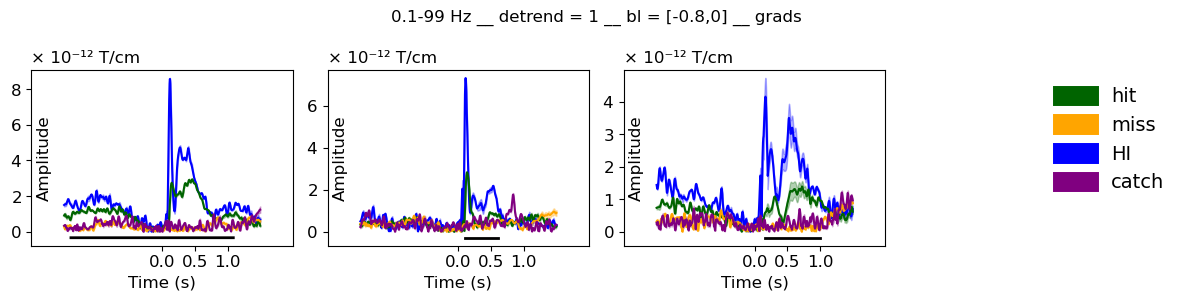

bestCh indices (per condition):  [array([206,  46]), array([46, 79]), array([ 74, 229])]
Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-2.7883344404666497 max=9.116217388818047
Running initial clustering …
Found 12 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.216997613508683 max=8.320306668938056
Running initial clustering …
Found 4 clusters


/tmp/ipykernel_3617670/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.0989637550710394 max=5.845094879686143
Running initial clustering …
Found 22 clusters


/tmp/ipykernel_3617670/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

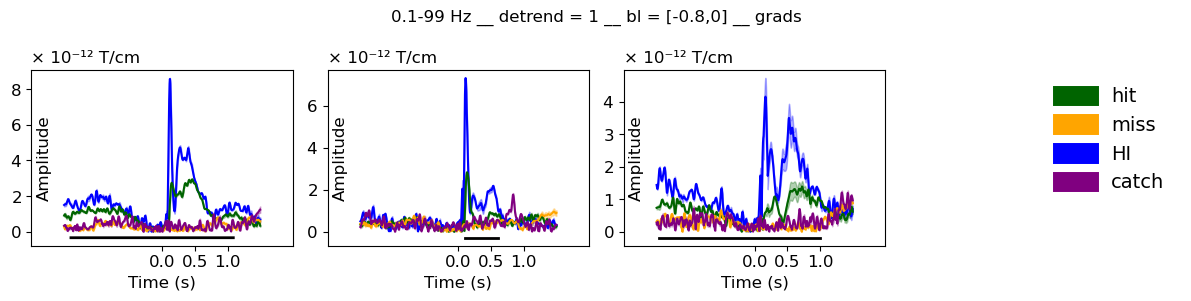

bestCh indices (per condition):  [array([137,  30]), array([30, 52]), array([ 49, 152])]
Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-2.430679098123141 max=9.467073922674583
Running initial clustering …
Found 15 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.216997613508683 max=8.320306668938056
Running initial clustering …
Found 4 clusters


/tmp/ipykernel_3617670/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-2.3131937084377503 max=4.462815451141297
Running initial clustering …
Found 17 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

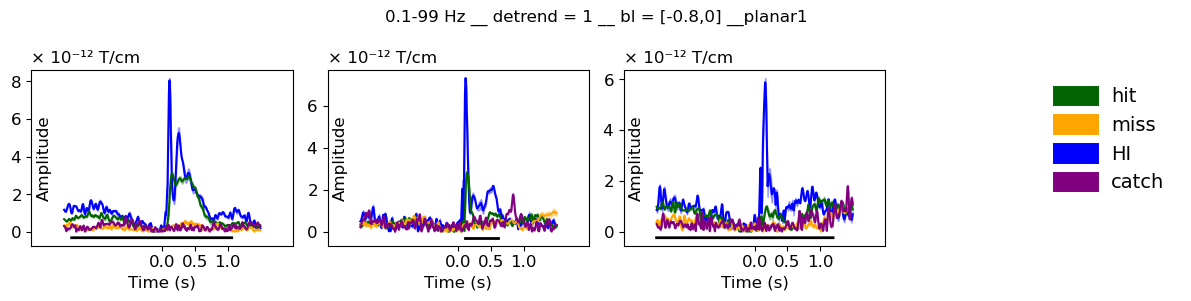

bestCh indices (per condition):  [array([40, 15]), array([15, 26]), array([74, 76])]
Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-2.3584451043455132 max=8.83552557884526
Running initial clustering …
Found 14 clusters


/tmp/ipykernel_3617670/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.5926892861578104 max=8.343124756395918
Running initial clustering …
Found 10 clusters


/tmp/ipykernel_3617670/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.4158379881888528 max=6.246488479443783
Running initial clustering …
Found 10 clusters


/tmp/ipykernel_3617670/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

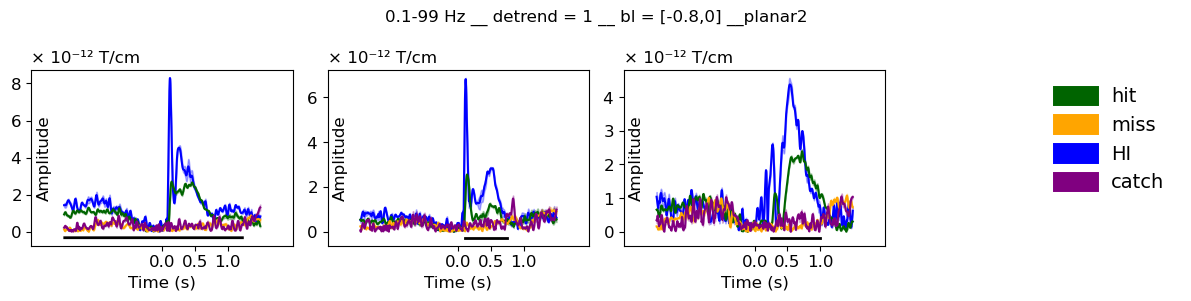

bestCh indices (per condition):  [array([ 6, 68]), array([85,  6]), array([25, 24])]


In [10]:
bestCh_idxs = plot_evoked(evoked_loaded, xlim = (-2, 2), ch_type = 'meg', title = '0.1-99 Hz __ detrend = 1 __ bl = [-0.8,0] __ grads')
print('bestCh indices (per condition): ', bestCh_idxs)
bestCh_idxs = plot_evoked(evoked_loaded, xlim = (-2, 2), ch_type = 'grad', title = '0.1-99 Hz __ detrend = 1 __ bl = [-0.8,0] __ grads')
print('bestCh indices (per condition): ', bestCh_idxs)
bestCh_idxs = plot_evoked(evoked_loaded, xlim = (-2, 2), ch_type = 'planar1', title = '0.1-99 Hz __ detrend = 1 __ bl = [-0.8,0] __planar1')
print('bestCh indices (per condition): ', bestCh_idxs)
bestCh_idxs = plot_evoked(evoked_loaded, xlim = (-2, 2), ch_type = 'planar2', title = '0.1-99 Hz __ detrend = 1 __ bl = [-0.8,0] __planar2')
print('bestCh indices (per condition): ', bestCh_idxs)

#### individual subjects

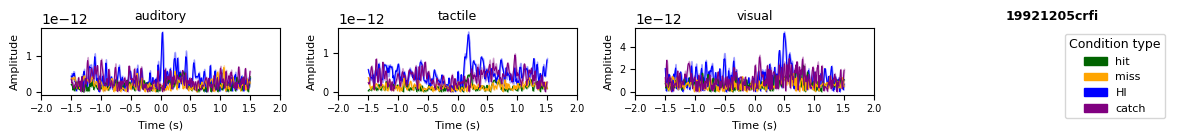

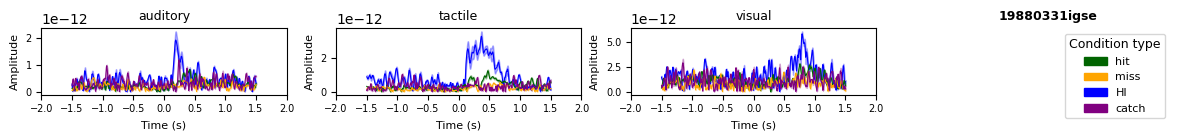

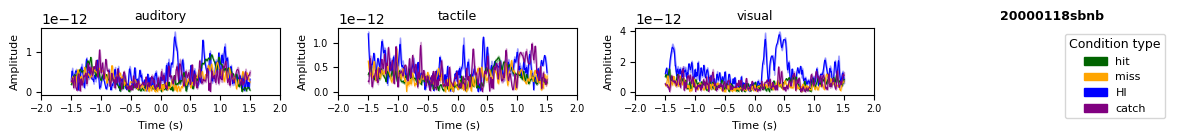

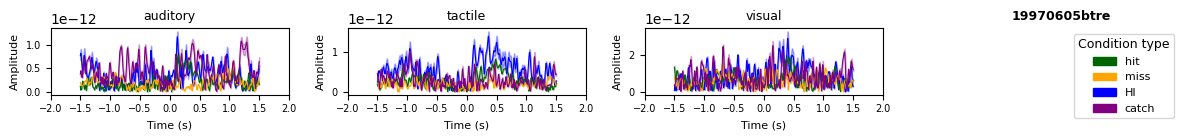

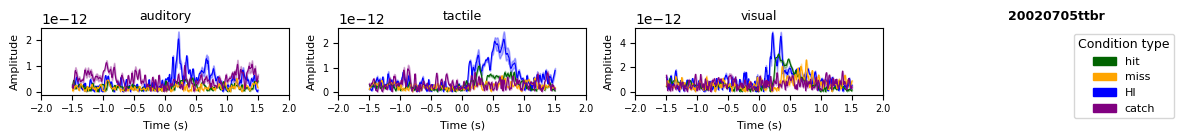

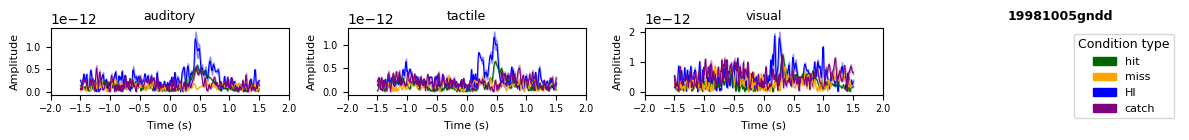

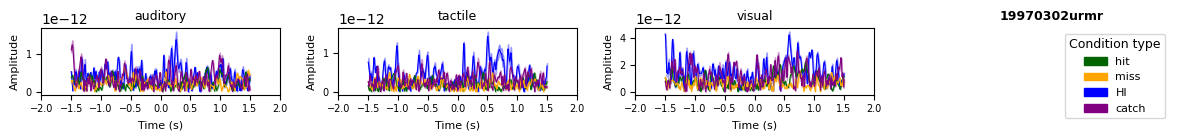

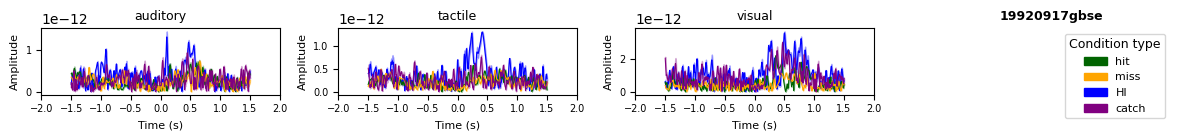

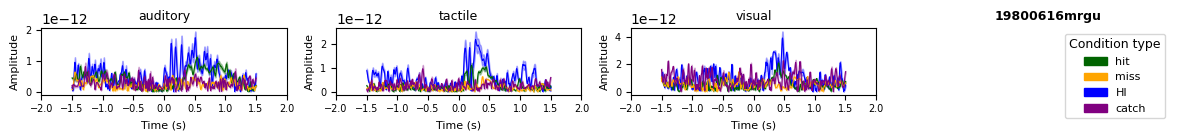

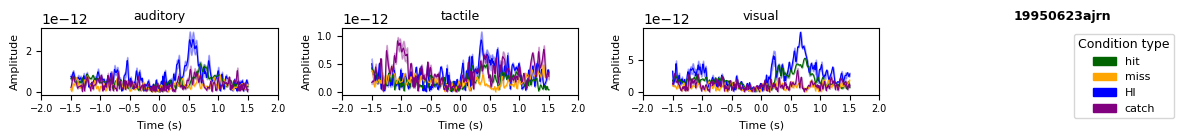

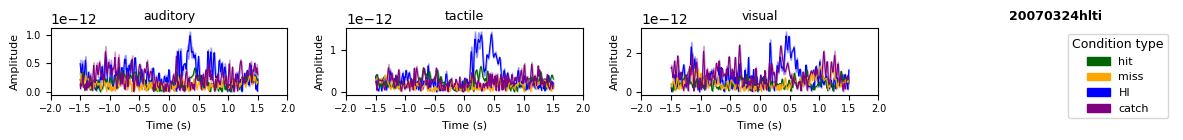

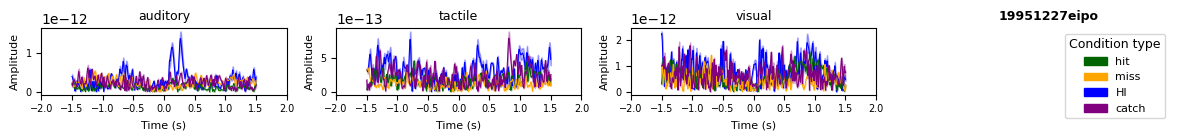

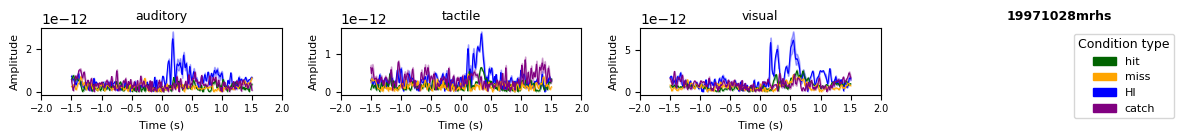

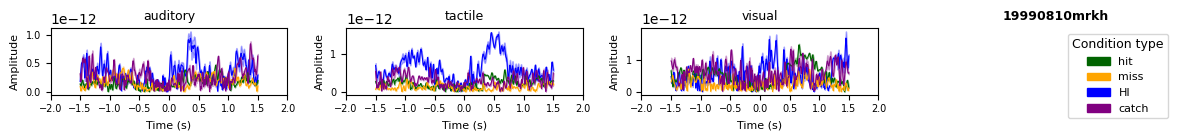

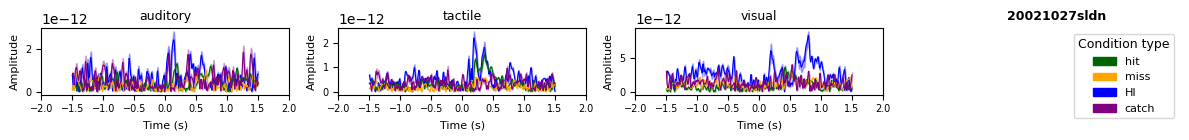

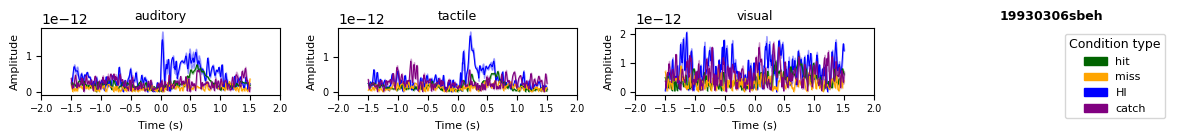

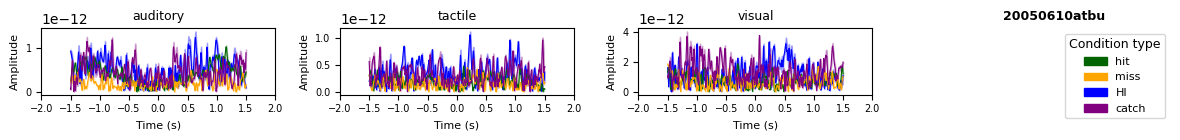

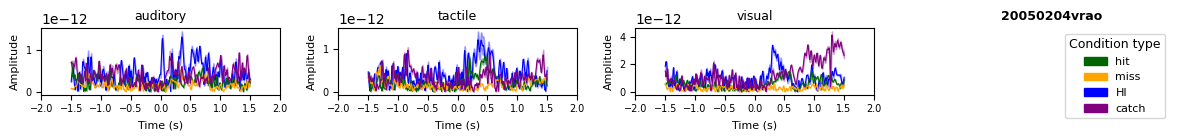

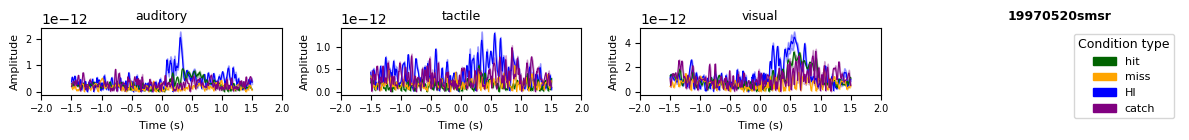

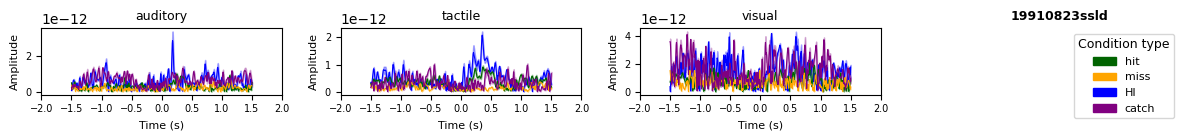

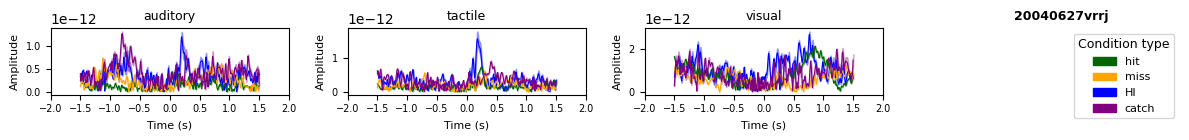

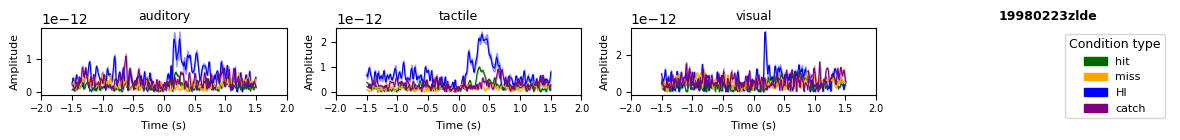

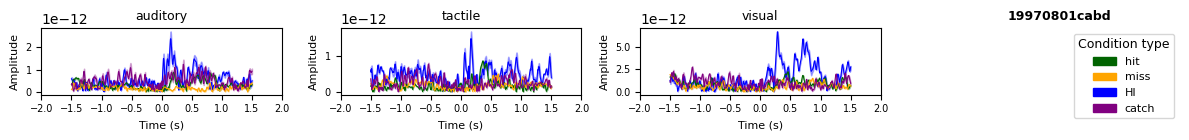

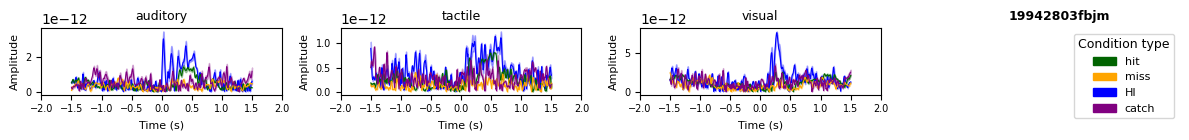

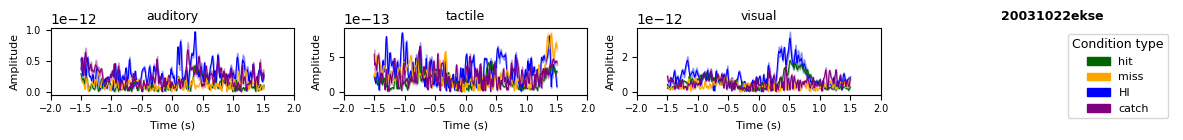

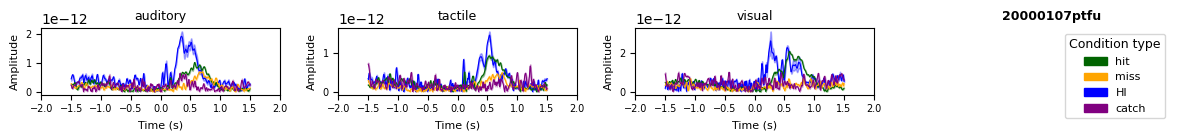

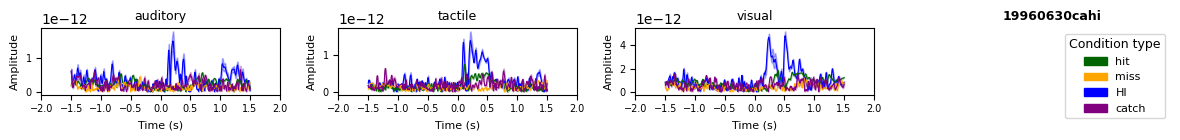

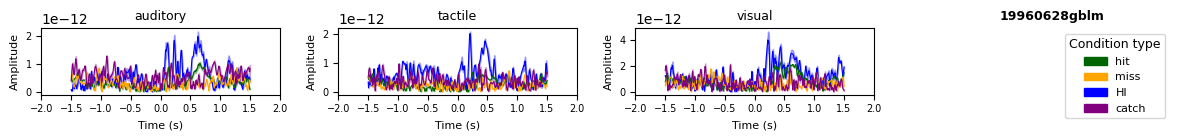

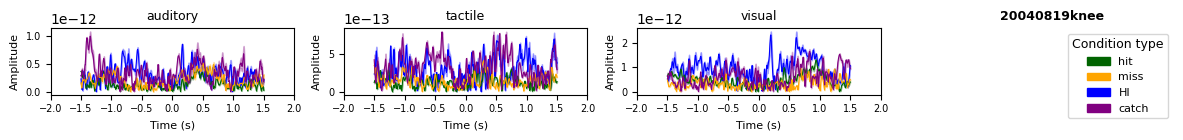

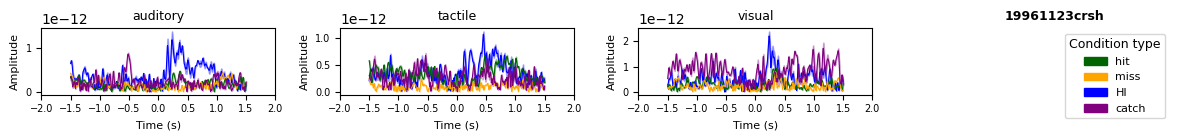

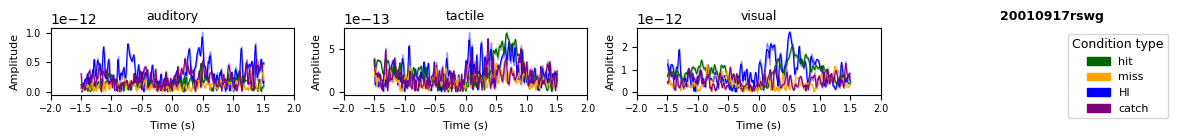

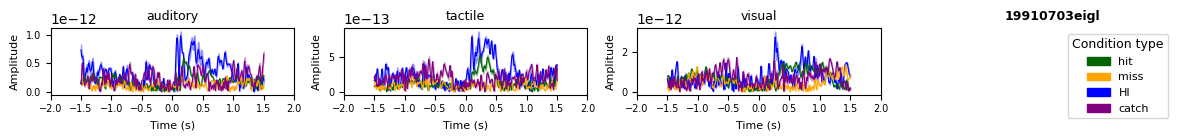

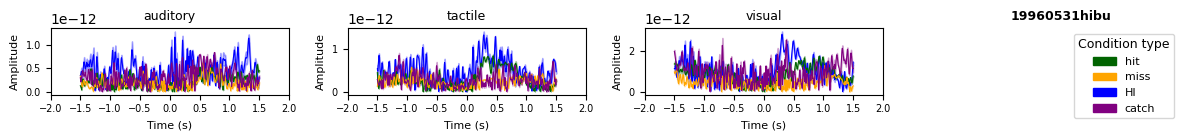

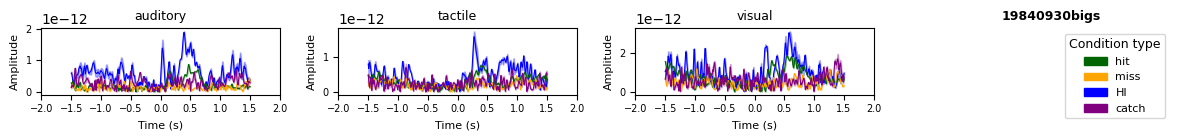

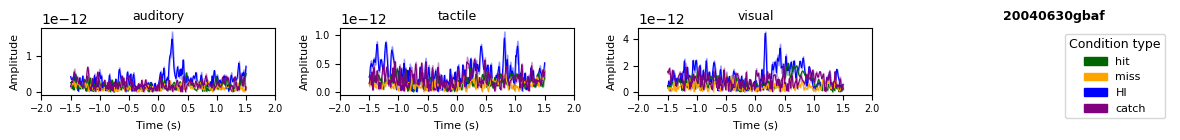

In [14]:
plot_evoked_all_subj(evoked_loaded, bestCh_idxs, xlim = (-2, 2),ylim=None)

### HP 0.5 -- bl [-0.2, 0] -- detrend = 0

In [15]:
inFile = os.path.join(MEG_EPOCHS_DIR, 'tmp_evoked_35subj_maxfilter_True__ica_True__0.5-NoneHz__fs_1000__[-1.5_1.5]s_detrend_0__bl_[-0.2_0]_lp_20.pkl')
evoked_loaded = joblib.load(inFile)

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.126655893205901 max=10.19691813252194
Running initial clustering …
Found 18 clusters


/tmp/ipykernel_1379096/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.560860527827762 max=6.516684130146947
Running initial clustering …
Found 8 clusters


/tmp/ipykernel_1379096/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.8373586395362014 max=8.282162987603838
Running initial clustering …
Found 8 clusters


/tmp/ipykernel_1379096/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

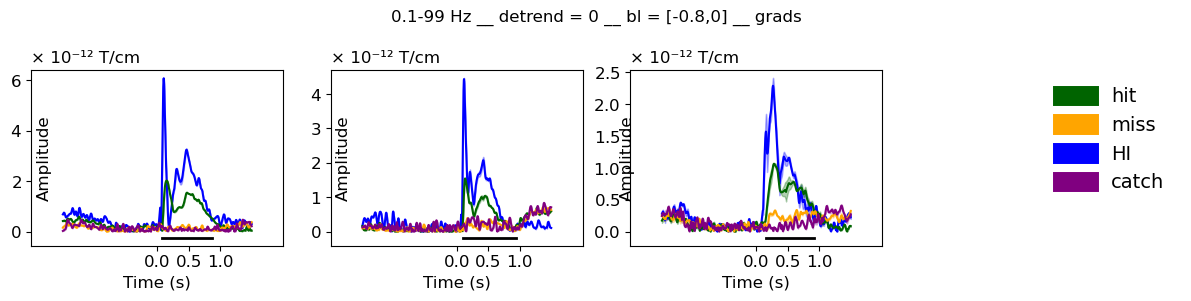

bestCh indices (per condition):  [array([95, 97]), array([13, 14]), array([184,  95])]
Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-4.236382860773679 max=11.41884000302374
Running initial clustering …
Found 12 clusters


/tmp/ipykernel_1379096/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-2.4071400077732736 max=9.292421144277624
Running initial clustering …
Found 6 clusters


/tmp/ipykernel_1379096/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-2.5950938570901214 max=7.536434202254371
Running initial clustering …
Found 11 clusters


/tmp/ipykernel_1379096/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

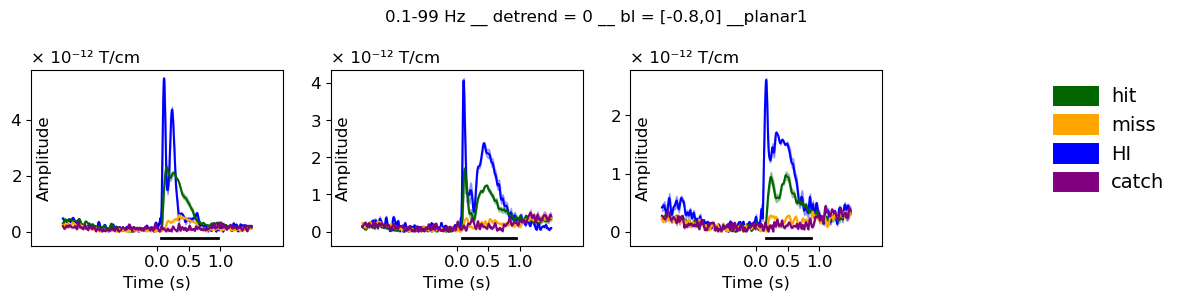

bestCh indices (per condition):  [array([47, 48]), array([47,  7]), array([86, 92])]
Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.126655893205901 max=10.19691813252194
Running initial clustering …
Found 18 clusters


/tmp/ipykernel_1379096/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.540890170305653 max=10.404435333062816
Running initial clustering …
Found 11 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.3247494357028726 max=6.090741982611235
Running initial clustering …
Found 8 clusters


/tmp/ipykernel_1379096/496129311.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

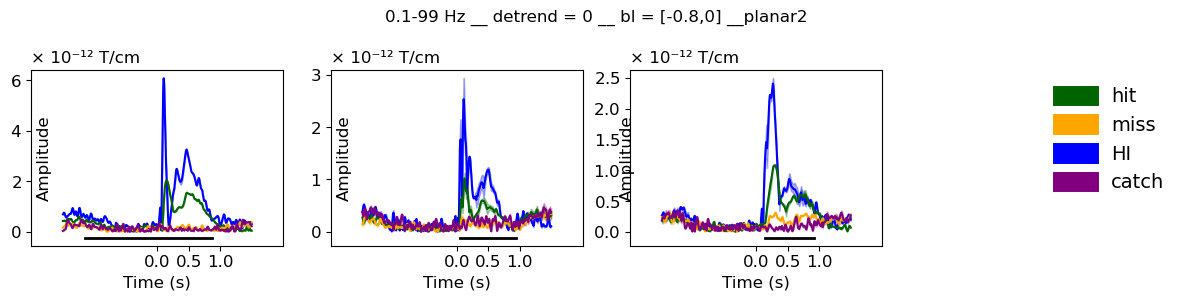

bestCh indices (per condition):  [array([47, 48]), array([40,  6]), array([95, 47])]


In [55]:
bestCh_idxs = plot_evoked(evoked_loaded, xlim = (-2, 2), ch_type = 'grad', title = '0.1-99 Hz __ detrend = 0 __ bl = [-0.8,0] __ grads')
print('bestCh indices (per condition): ', bestCh_idxs)
bestCh_idxs = plot_evoked(evoked_loaded, xlim = (-2, 2), ch_type = 'planar1', title = '0.1-99 Hz __ detrend = 0 __ bl = [-0.8,0] __planar1')
print('bestCh indices (per condition): ', bestCh_idxs)
bestCh_idxs = plot_evoked(evoked_loaded, xlim = (-2, 2), ch_type = 'planar2', title = '0.1-99 Hz __ detrend = 0 __ bl = [-0.8,0] __planar2')
print('bestCh indices (per condition): ', bestCh_idxs)

### HP 0.5 -- bl [0,2, 0] -- detrend = 0

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.683520928723011 max=9.812571181011112
Running initial clustering …
Found 11 clusters


/tmp/ipykernel_1379096/4135483646.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.559595549988163 max=6.839970629140979
Running initial clustering …
Found 8 clusters


/tmp/ipykernel_1379096/4135483646.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.4178732139728387 max=7.725193973077277
Running initial clustering …
Found 9 clusters


/tmp/ipykernel_1379096/4135483646.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

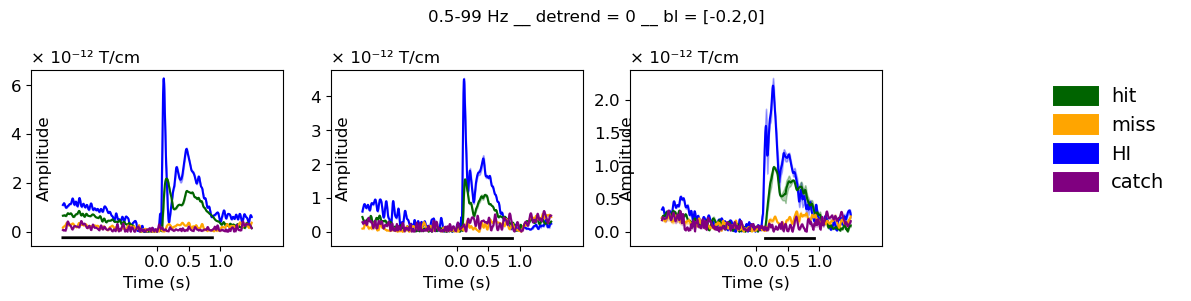

bestCh indices (per condition):  [array([95, 97]), array([13, 14]), array([ 95, 184])]


In [ ]:
inFile = os.path.join(MEG_EPOCHS_DIR, 'tmp_evoked_35subj_maxfilter_True__ica_True__0.5-NoneHz__fs_1000__[-1.5_1.5]s_detrend_0__bl_[-0.2_0]_lp_20.pkl')
evoked_loaded = joblib.load(inFile)
title = '0.5-99 Hz __ detrend = 0 __ bl = [-0.2,0]'
# plot_evoked(evoked_loaded, xlim = (-0.2, 1), title = title	)
bestCh_idxs = plot_evoked(evoked_loaded, xlim = (-2, 2), title = title)
print('bestCh indices (per condition): ', bestCh_idxs)

#### individual subjects

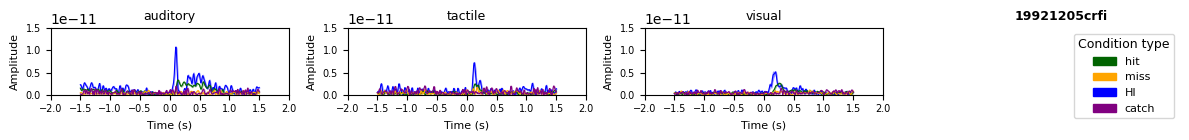

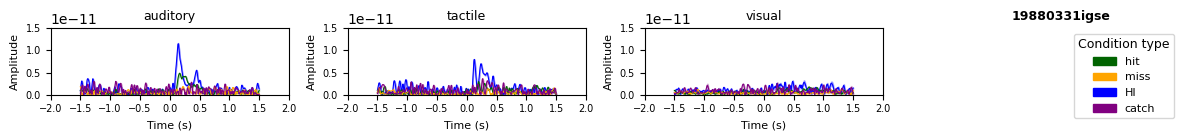

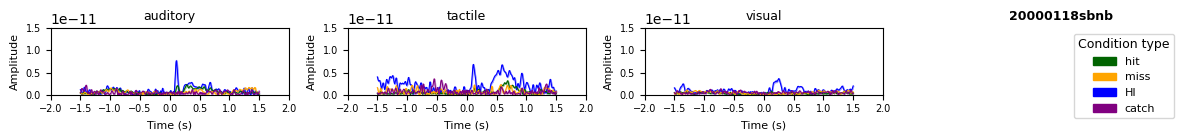

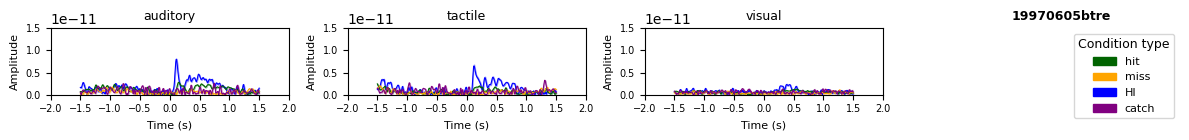

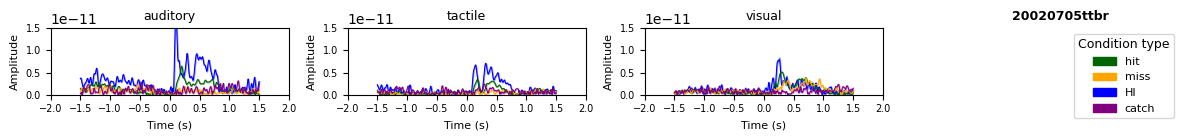

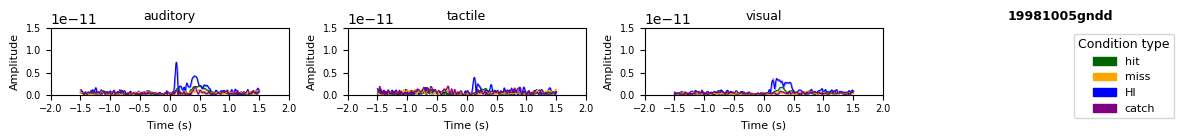

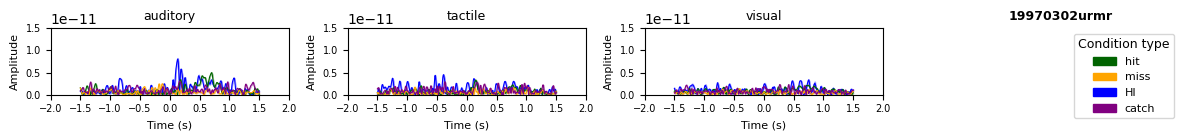

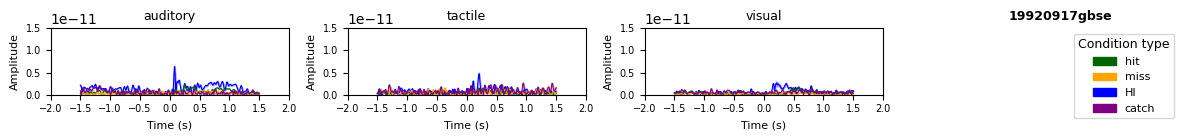

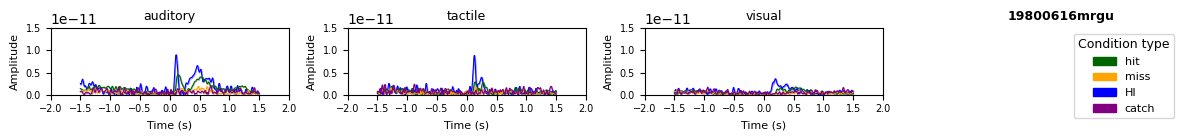

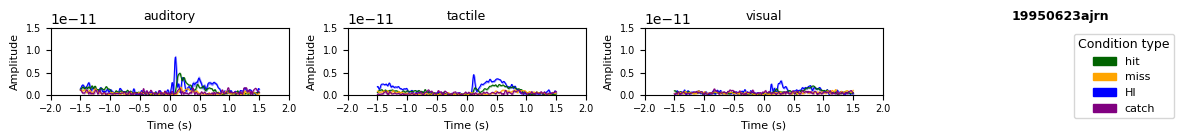

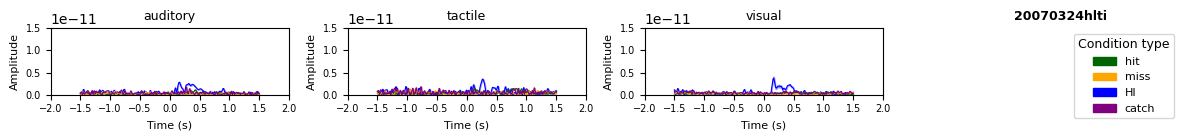

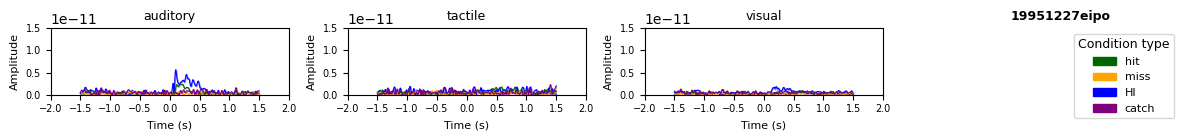

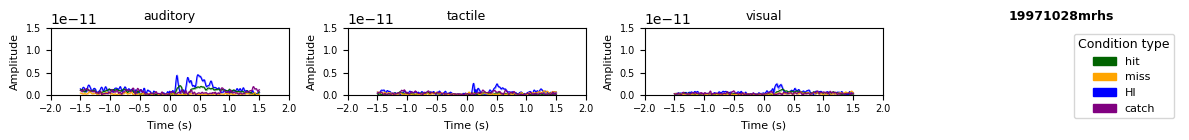

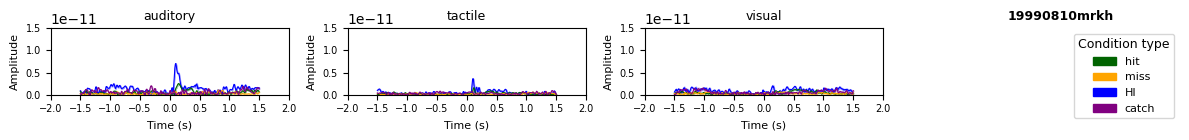

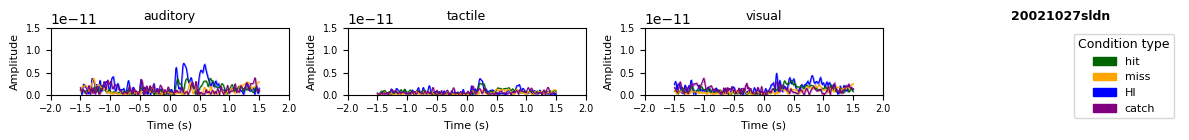

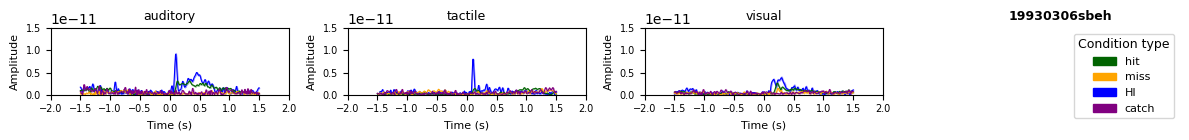

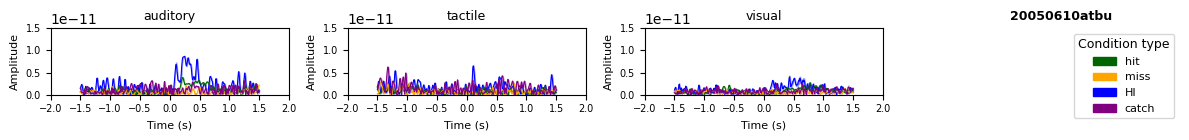

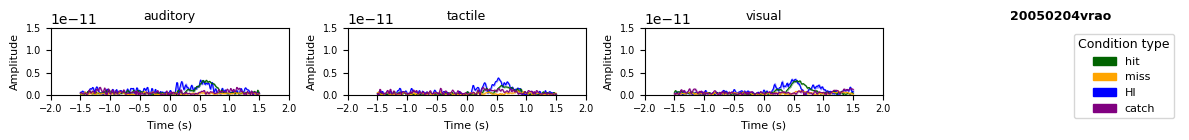

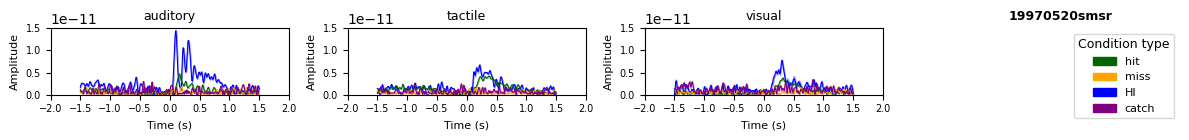

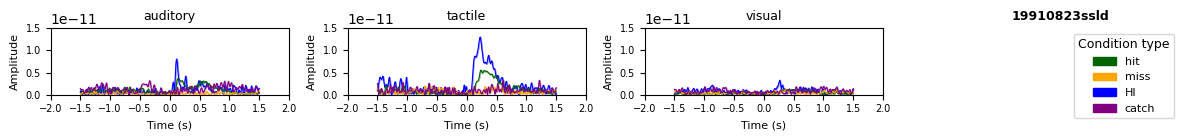

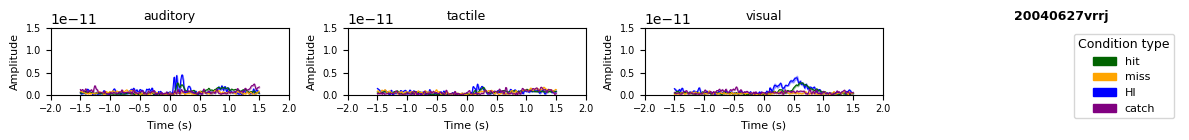

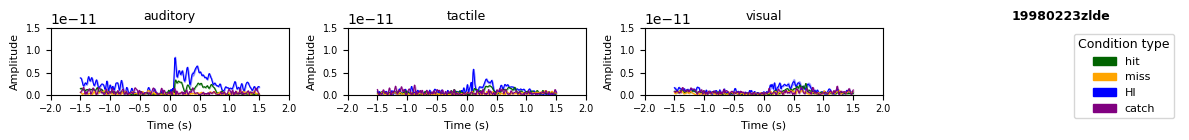

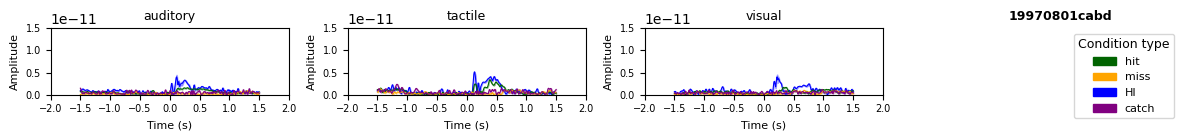

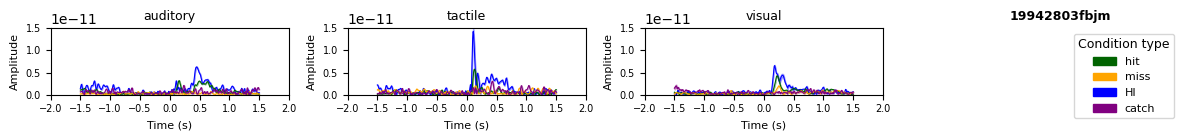

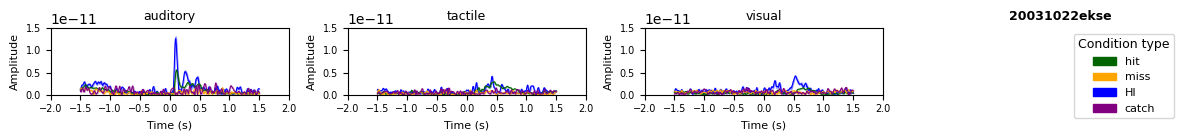

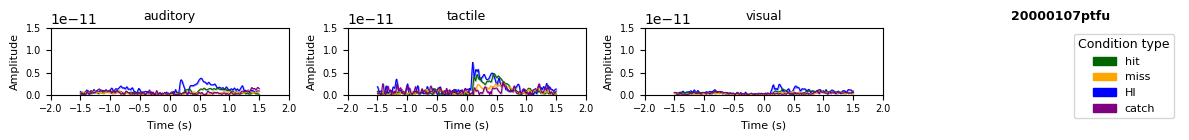

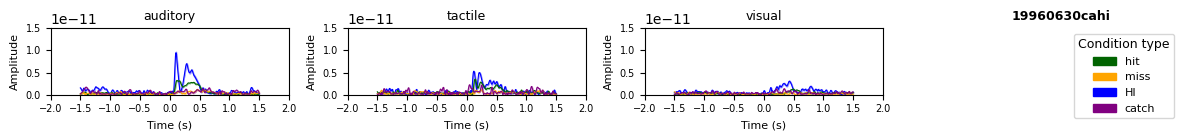

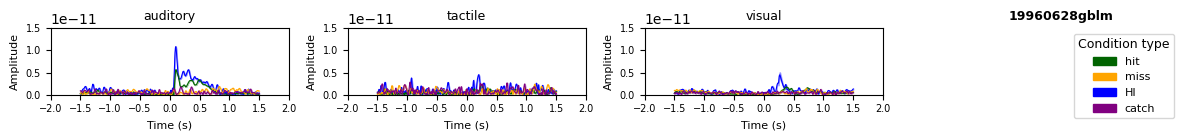

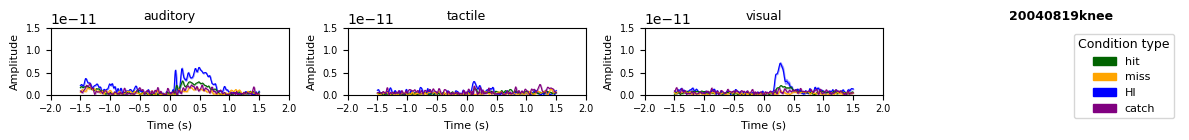

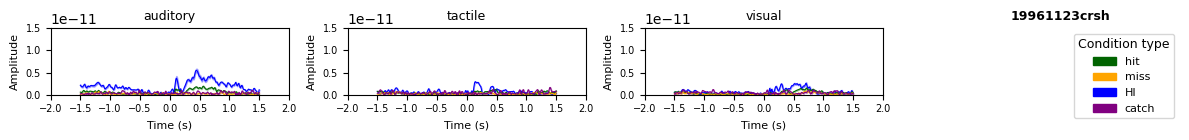

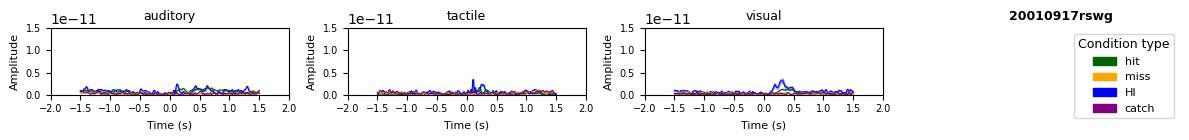

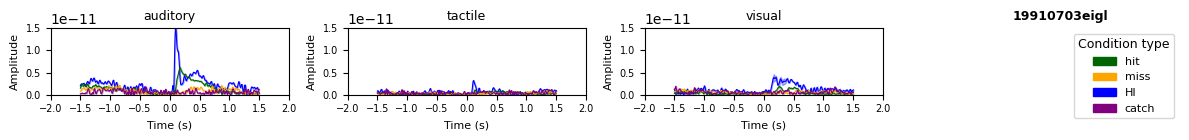

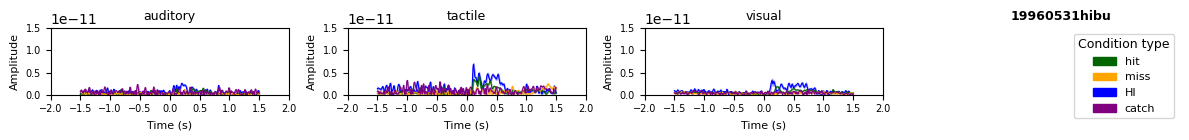

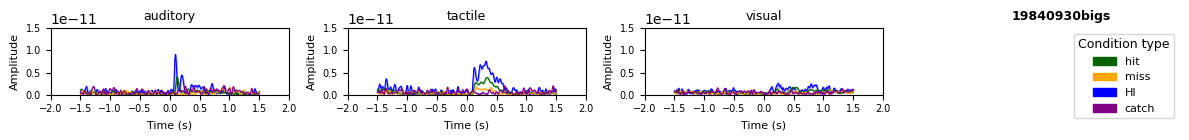

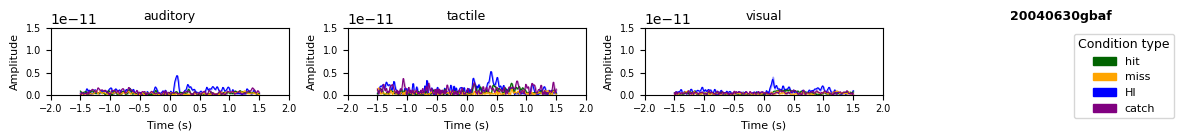

In [23]:
plot_evoked_all_subj(evoked_loaded, bestCh_idxs, xlim = (-2, 2))

### HP 0.5 -- bl [0,2, 0] -- detrend = 1

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.691085058179513 max=9.738328550255025
Running initial clustering …
Found 10 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.618195919825106 max=7.036692582933496
Running initial clustering …
Found 6 clusters


/tmp/ipykernel_1379096/4135483646.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Identifying common channels ...
Using a threshold of 1.690924
stat_fun(H1): min=-3.7633160026109214 max=7.484158627496949
Running initial clustering …
Found 10 clusters


/tmp/ipykernel_1379096/4135483646.py:70: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

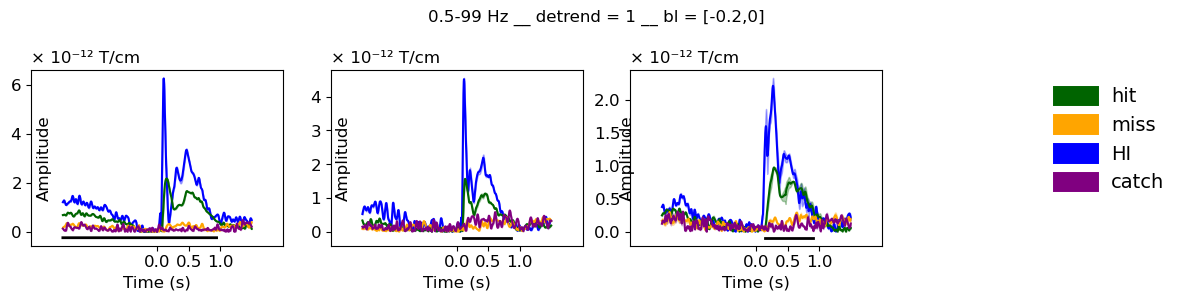

bestCh indices (per condition):  [array([95, 97]), array([13, 14]), array([184,  95])]


In [ ]:
inFile = os.path.join(MEG_EPOCHS_DIR, 'tmp_evoked_35subj_maxfilter_True__ica_True__0.5-NoneHz__fs_1000__[-1.5_1.5]s_detrend_1__bl_[-0.2_0]_lp_20.pkl')
evoked_loaded = joblib.load(inFile)
title = '0.5-99 Hz __ detrend = 1 __ bl = [-0.2,0]'
# plot_evoked(evoked_loaded, xlim = (-0.2, 1), title = title	)
bestCh_idxs = plot_evoked(evoked_loaded, xlim = (-2, 2), title = title)
print('bestCh indices (per condition): ', bestCh_idxs)

# evoked Topo plots

In [57]:

# evoked = deepcopy(evoked_loaded)
# all_subj = os.listdir('/home/reabt/experiments/ncc/MEG/data/epochs_all_conditions/')
# times = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]
# ch_type = 'mag'

# # für colorbar:
# orientation = 'horizontal' 
# 			# orientation = 'vertical'
# fontsize = 25

# with warnings.catch_warnings():
# 	warnings.simplefilter("ignore")
# 	with mne.use_log_level('ERROR'):
# 		fig, axes = mk_subplots(3, len(times) + 1, False)

# 		for n, condition in enumerate(NT_hits):
# 			ga_cond = mne.grand_average(
# 				[evo[condition].copy() for evo, subjID in zip(evoked, all_subj)
# 				 if (evo and subjID not in badSubj)]
# 			)

# 			topo_axes = axes[n, :len(times)]
# 			cbar_ax = axes[n, len(times)]

# 			evoked4plt = ga_cond.copy().pick(ch_type)
# 			evoked4plt.set_channel_types(
# 				dict(zip(evoked4plt.ch_names, np.tile('eeg', len(evoked4plt.ch_names)))),
# 				verbose=False
# 			)

# 			evoked4plt.plot_topomap(
# 				times=times,
# 				axes=topo_axes,
# 				ch_type="eeg",
# 				show=False,
# 				colorbar=False,
# 				outlines="head",
# 				extrapolate="head",
# 				contours=6,
# 				sphere=0.17
# 			)

# 			# get one mappable from THIS row
# 			row_mappable = None
# 			for a in topo_axes:
# 				if len(a.images) > 0:
# 					row_mappable = a.images[0]
# 					break
# 				elif len(a.collections) > 0:
# 					row_mappable = a.collections[0]
# 					break

# 			# ~~~~~ COLORBAR				
# 			# create colorbar inside the 8th subplot axis
# 			cbar_ax = axes[n, len(times)]
# 			cbar_ax.set_axis_off()

# 			if orientation == 'horizontal':
# 				inset_axes_kwargs = dict(
# 					width="85%",    # width relative to the 8th subplot axis
# 					height="12%",   # height relative to the 8th subplot axis
# 					loc="center")
# 			elif orientation == 'vertical':
# 				inset_axes_kwargs = dict(width="12%", height="80%", loc="center left")
			
# 			inner_cax = inset_axes(cbar_ax, **inset_axes_kwargs)
			
# 			cb = fig.colorbar(row_mappable, cax=inner_cax, orientation=orientation, ticklocation='top')
# 			cb.ax.tick_params(labelsize=fontsize)

# 			fig.canvas.draw() # sonst haben wir den Text vom offset noch nicht, weil er oft erst am schluss generiert wird

# 			exponent_formatter_cb(cb, 
# 						 orientation=orientation, 
# 						 fontsize = fontsize, 
# 						 labelpad = -82)

# 			# ~~~~~ TITLES
# 			if n == 0:
# 				for a in topo_axes:
# 					a.set_title(f"{a.get_title().strip('0.').strip(' s')} ms", fontsize=30)
# 			else:
# 				for a in topo_axes:
# 					a.title.set_visible(False)

# 		plt.subplots_adjust(
# 			left=0.02,
# 			right=0.98,
# 			top=0.95,
# 			bottom=0.10,
# 			wspace=-0.05,
# 			hspace=-0.05
# 		)
		
# 		plt.show()




FileNotFoundError: [Errno 2] No such file or directory: '/home/reabt/experiments/ncc/MEG/data/epochs_all_conditions/'

Identifying common channels ...


/tmp/ipykernel_1379096/6803422.py:25: RuntimeWarning: The unit for channel(s) MEG0111, MEG0121, MEG0131, MEG0141, MEG0211, MEG0221, MEG0231, MEG0241, MEG0311, MEG0321, MEG0331, MEG0341, MEG0411, MEG0421, MEG0431, MEG0441, MEG0511, MEG0521, MEG0531, MEG0541, MEG0611, MEG0621, MEG0631, MEG0641, MEG0711, MEG0721, MEG0731, MEG0741, MEG0811, MEG0821, MEG0911, MEG0921, MEG0931, MEG0941, MEG1011, MEG1021, MEG1031, MEG1041, MEG1111, MEG1121, MEG1131, MEG1141, MEG1211, MEG1221, MEG1231, MEG1241, MEG1311, MEG1321, MEG1331, MEG1341, MEG1411, MEG1421, MEG1431, MEG1441, MEG1511, MEG1521, MEG1531, MEG1541, MEG1611, MEG1621, MEG1631, MEG1641, MEG1711, MEG1721, MEG1731, MEG1741, MEG1811, MEG1821, MEG1831, MEG1841, MEG1911, MEG1921, MEG1931, MEG1941, MEG2011, MEG2021, MEG2031, MEG2041, MEG2111, MEG2121, MEG2131, MEG2141, MEG2211, MEG2221, MEG2231, MEG2241, MEG2311, MEG2321, MEG2331, MEG2341, MEG2411, MEG2421, MEG2431, MEG2441, MEG2511, MEG2521, MEG2531, MEG2541, MEG2611, MEG2621, MEG2631, MEG2641 has c

Identifying common channels ...


/tmp/ipykernel_1379096/6803422.py:25: RuntimeWarning: The unit for channel(s) MEG0111, MEG0121, MEG0131, MEG0141, MEG0211, MEG0221, MEG0231, MEG0241, MEG0311, MEG0321, MEG0331, MEG0341, MEG0411, MEG0421, MEG0431, MEG0441, MEG0511, MEG0521, MEG0531, MEG0541, MEG0611, MEG0621, MEG0631, MEG0641, MEG0711, MEG0721, MEG0731, MEG0741, MEG0811, MEG0821, MEG0911, MEG0921, MEG0931, MEG0941, MEG1011, MEG1021, MEG1031, MEG1041, MEG1111, MEG1121, MEG1131, MEG1141, MEG1211, MEG1221, MEG1231, MEG1241, MEG1311, MEG1321, MEG1331, MEG1341, MEG1411, MEG1421, MEG1431, MEG1441, MEG1511, MEG1521, MEG1531, MEG1541, MEG1611, MEG1621, MEG1631, MEG1641, MEG1711, MEG1721, MEG1731, MEG1741, MEG1811, MEG1821, MEG1831, MEG1841, MEG1911, MEG1921, MEG1931, MEG1941, MEG2011, MEG2021, MEG2031, MEG2041, MEG2111, MEG2121, MEG2131, MEG2141, MEG2211, MEG2221, MEG2231, MEG2241, MEG2311, MEG2321, MEG2331, MEG2341, MEG2411, MEG2421, MEG2431, MEG2441, MEG2511, MEG2521, MEG2531, MEG2541, MEG2611, MEG2621, MEG2631, MEG2641 has c

Identifying common channels ...


/tmp/ipykernel_1379096/6803422.py:25: RuntimeWarning: The unit for channel(s) MEG0111, MEG0121, MEG0131, MEG0141, MEG0211, MEG0221, MEG0231, MEG0241, MEG0311, MEG0321, MEG0331, MEG0341, MEG0411, MEG0421, MEG0431, MEG0441, MEG0511, MEG0521, MEG0531, MEG0541, MEG0611, MEG0621, MEG0631, MEG0641, MEG0711, MEG0721, MEG0731, MEG0741, MEG0811, MEG0821, MEG0911, MEG0921, MEG0931, MEG0941, MEG1011, MEG1021, MEG1031, MEG1041, MEG1111, MEG1121, MEG1131, MEG1141, MEG1211, MEG1221, MEG1231, MEG1241, MEG1311, MEG1321, MEG1331, MEG1341, MEG1411, MEG1421, MEG1431, MEG1441, MEG1511, MEG1521, MEG1531, MEG1541, MEG1611, MEG1621, MEG1631, MEG1641, MEG1711, MEG1721, MEG1731, MEG1741, MEG1811, MEG1821, MEG1831, MEG1841, MEG1911, MEG1921, MEG1931, MEG1941, MEG2011, MEG2021, MEG2031, MEG2041, MEG2111, MEG2121, MEG2131, MEG2141, MEG2211, MEG2221, MEG2231, MEG2241, MEG2311, MEG2321, MEG2331, MEG2341, MEG2411, MEG2421, MEG2431, MEG2441, MEG2511, MEG2521, MEG2531, MEG2541, MEG2611, MEG2621, MEG2631, MEG2641 has c

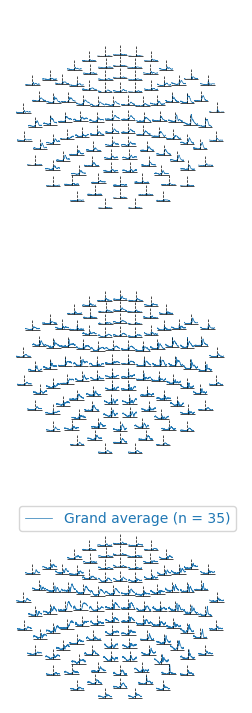

In [65]:

evoked = deepcopy(evoked_loaded)
all_subj = MEG_subjects()
times = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]
ch_type = 'all'

fig, axes = mk_subplots(3, 1, False)

for n, condition in enumerate(NT_hits):
	ga_cond = mne.grand_average([evo[condition].copy() for evo, subjID in zip(evoked, all_subj)])
	topo_axes = axes[n, ]

	evoked4plt = ga_cond.copy().pick(ch_type)
	evoked4plt.set_channel_types(
		dict(zip(evoked4plt.ch_names, np.tile('eeg', len(evoked4plt.ch_names)))),
		verbose=False
	)

	ga_cond.plot_topo(
		axes=topo_axes,
		show=False,
		merge_grads = True
	)
plt.show()

In [ ]:

evoked = deepcopy(evoked_loaded)
all_subj = MEG_subjects()
times = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]
ch_type = 'all'

fig, axes = mk_subplots(3, 1, False)

for n, condition in enumerate(NT_hits):
	ga_cond = mne.grand_average([evo[condition].copy() for evo, subjID in zip(evoked, all_subj)])
	topo_axes = axes[n, ]

	# evoked4plt = ga_cond.copy().pick(ch_type)
	# evoked4plt.set_channel_types(
	# 	dict(zip(evoked4plt.ch_names, np.tile('eeg', len(evoked4plt.ch_names)))),
	# 	verbose=False
	# )
	mne.viz.plot_evoked_topo(ga_cond)
	ga_cond.plot_topo(
		axes=topo_axes,
		show=False,
		merge_grads = True
	)
plt.show()

# Test: combining gradiometers

In [ ]:
tmpFile = '/home/scc_e_393956/Desktop/reabt/ncc/MEG/epochs_clean/manual_finish/19840930bigs/19840930bigs_maxfilter_True__ica_True__0.1-NoneHz__fs_1000__[-1.5_1.5]s_detrend_0_meg_clean-epo.fif'
info = mne.io.read_info(tmpFile)

In [44]:
ga_mod.pick(picks)

IndexError: index 103 is out of bounds for axis 0 with size 102

In [39]:
evoked[0][conditions2[0][0]].data[picks]

array([[-9.48520990e-13, -9.50697177e-13, -9.50971769e-13, ...,
        -7.22218564e-13, -7.34397779e-13, -7.46036943e-13],
       [-4.74182230e-15, -2.68581590e-14, -4.76132420e-14, ...,
         6.46044048e-13,  6.27040427e-13,  6.07448336e-13],
       [-8.97644430e-13, -8.65088338e-13, -8.30158119e-13, ...,
         1.45421956e-13,  1.31036724e-13,  1.16421519e-13],
       ...,
       [-9.65859737e-14, -1.20994284e-13, -1.46121932e-13, ...,
        -8.11990367e-13, -8.07229280e-13, -7.97383318e-13],
       [ 1.84067312e-12,  1.83404540e-12,  1.82479639e-12, ...,
         5.08889807e-13,  5.26555358e-13,  5.46901452e-13],
       [ 1.67133039e-12,  1.69293150e-12,  1.71192632e-12, ...,
         3.41712054e-13,  3.63621502e-13,  3.84737863e-13]],
      shape=(204, 3001))

In [43]:
dir(ga_mod)

['__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__neg__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_aspect_kind',
 '_data',
 '_decim',
 '_get_channel_positions',
 '_handle_tmin_tmax',
 '_pick_drop_channels',
 '_pick_projs',
 '_projector',
 '_raw_times',
 '_reconstruct_proj',
 '_repr_html_',
 '_set_channel_positions',
 '_set_legacy_nfft_default',
 '_set_times',
 '_size',
 '_times_readonly',
 '_update_first_last',
 'add_channels',
 'add_proj',
 'add_reference_channels',
 'animate_topomap',
 'anonymize',
 'apply_baseline',
 'apply_function',
 'apply_hilbert',
 'apply_proj',
 'as_type',
 'baseline',
 'ch_names',
 

Identifying common channels ...
len picks:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203]
['MEG0112', 'MEG0113', 'MEG0122', 'MEG0123', 

IndexError: index 102 is out of bounds for axis 0 with size 102

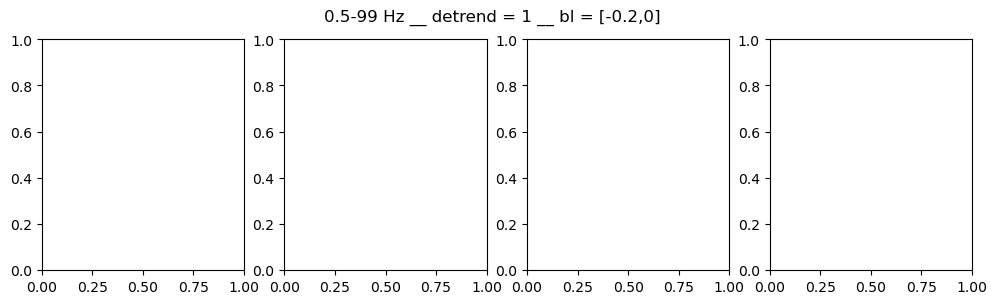

In [47]:
from mne.channels.layout import _pair_grad_sensors, _merge_grad_data
xlim = (-2, 2)
ylim = (0, -1.5e-11)
evoked = evoked_loaded.copy()
times = evoked[0]['HI/visual'].times

n_best = 2
ch_type = 'grad'
# all_subj = os.listdir('/home/reabt/experiments/ncc/MEG/data/epochs_all_conditions/')
all_subj = MEG_subjects()
badSubj = []
bestCh_idxs = []

fig, axes = mk_subplots(1, 4, False, facecolor = None)
fig.suptitle(title)
# fig.set_facecolor(None)
fig.set_alpha(0)
for n, (modality, mod_name) in enumerate(zip(conditions2, titles)):
	ax = axes[n]


	ga_mod = mne.grand_average(
		[evo[modality[0]] for evo, subjID in zip(evoked, all_subj)
		 if (evo and subjID not in badSubj)]
	)

	# print(ga_mod)
	ga_mod = ga_mod.pick('grad')
	#----------------------------------
	
	picks = _pair_grad_sensors(ga_mod.info, topomap_coords=False)
	print('len picks: ', picks)
	ch_names = ga_mod.ch_names
	print(ch_names)

	if picks is not None:
		ga_mod.pick(picks)

	print('channels after:', ga_mod.ch_names)

	ga_mod.data = _merge_grad_data(ga_mod.data)
	# ga_mod.ch_names = [ch_name[:-1] + "X" for ch_name in ch_names[::2]]


# 		ga_mod = mne.grand_average(
# 		[evo[modality[0]] for evo, subjID in zip(evoked, all_subj)
# 		 if (evo and subjID not in badSubj)]
# 	)
	#----------------------------------
	evoked_mod = ga_mod.copy().pick(ch_type)
	max_activity = np.max(np.abs(evoked_mod.data), axis=1)
	bestCh_idx = np.argsort(max_activity)[-n_best:]
	bestCh_idxs.append(bestCh_idx)

	for n_cond, condition in enumerate(modality):
		with mne.utils.use_log_level('ERROR'):
			ga_cond = mne.grand_average(
				[evo[condition] for evo, subjID in zip(evoked, all_subj)
				 if (evo and subjID not in badSubj)]
			)

		thisColor = next((v for k, v in colors.items() if k in condition), None)

		plot_best_evoked(
			ga_cond, bestCh_idx, ax,
			color=thisColor, ch_type=ch_type,
			do_avg=False, use_abs=True
		)
			
	# --- mk data 4 statistics
	data_hit  = []
	data_miss = []

	for evo, subjID in zip(evoked, all_subj):
		if evo and subjID not in badSubj:
			hit_key = modality[1]
			miss_key = modality[2]
			ev_hit  = evo[hit_key].copy().pick(ch_type)
			ev_miss = evo[miss_key].copy().pick(ch_type)

			# same "best channels" logic as before
			hit_data  = np.mean(np.abs(ev_hit.data[bestCh_idx]), axis=0)
			miss_data = np.mean(np.abs(ev_miss.data[bestCh_idx]), axis=0)

			data_hit.append(hit_data)
			data_miss.append(miss_data)

	data_hit  = np.array(data_hit)
	data_miss = np.array(data_miss)
	
	# --- do statistics A: t-test
	# t_vals, p_vals = ttest_rel(data_hit, data_miss, axis=0)
	# sig_mask = p_vals < 0.05

	# --- do statistics B: Cluster permutation
	X = data_hit - data_miss  # paired test
	T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)
	sig_mask = np.zeros(len(times), dtype=bool)
	sig_mask[np.concatenate([clu[0] for clu, p in zip(clusters, p_values) if p < 0.05])] = True

	ymin, ymax = ax.get_ylim()
	y_sig = ymin + 0.01 * (ymax - ymin)
	# print(f'sig. times in {modality}: {times[sig_mask]}')
	ax.plot(times[sig_mask],
			np.full(np.sum(sig_mask), y_sig),
			color='black', linewidth=2)

	# --- rest of the plot style stuff
	# ax.set_title(mod_name)
	ax.set_xlabel('Time (s)')
	ax.set_ylabel('Amplitude', labelpad=-30) #, fontsize=14)
	ax.set_xlim(xlim)
	ax.set_xticks([0, 0.5, 1])
	ax.set_facecolor('white') 
	# ax.set

	# scientific notation for ticks
	formatter = mticker.ScalarFormatter(useMathText=True)
	formatter.set_scientific(True)
	formatter.set_powerlimits((0, 0))
	ax.yaxis.set_major_formatter(formatter)
	ax.yaxis.get_offset_text().set_visible(False) # hide the automatically generated offset text
	ax.text(0.0, 1.02, '× 10⁻¹² T/cm', transform=ax.transAxes, ha='left', va='bottom', fontsize = 12) # add your own custom scaling/unit text

legend_handles = [mpatches.Patch(color=c, label=k, linewidth=5) for i, (k, c) in enumerate(colors.items())]
# legend_handles.append = mpatches.Patch(color='k', label='p<.0.05', linewidth=0.5) 
axes[3].axis('off')
axes[3].legend(handles=legend_handles, 
			#    title='Condition',
			facecolor=None, fancybox=True, framealpha=0, fontsize = 14)

scale = 1.2
plt.tight_layout()
for ax in axes[0:3]:
	ax.title.set_fontsize(12) #(ax.title.get_fontsize() * scale)
	ax.xaxis.label.set_size(12) #(ax.xaxis.label.get_size() * scale)
	ax.yaxis.label.set_size(12) #(ax.yaxis.label.get_size() * scale)

	for label in ax.get_xticklabels() + ax.get_yticklabels():
		label.set_fontsize(12) #(label.get_fontsize() * scale)
plt.show()


